#Brief introduction about the refine method.
The refine method is an implementation of the Document Chain strategy, specifically designed to handle large texts efficiently with LLMs.
Here's how it works:
1. Document Management:
* Takes input text that's already split into smaller documents
* Each document is processed sequentially
* Maintains a running state (current summary and document index)
2. Sequential Operation
* First document → Initial summary
* Next document + Current summary → Refined summary
* Repeats until all documents are processed

Key Advantage:

* Handles text larger than LLM's context window
* Maintains coherent understanding across chunks
* Each refinement builds upon previous knowledge

disadvantages:
* Can be slower than batch processing for smaller texts
* Increased processing time due to sequential nature

for more information : https://python.langchain.com/docs/versions/migrating_chains/refine_docs_chain/




#1. Installation
installing several libraries required for the summarization application.

In [ ]:
!pip install langchain-huggingface
!pip install --upgrade --quiet transformers
!pip install huggingface_hub
!pip install -qU langgraph
!pip install langchain_community
!pip install -qU langchain-text-splitters
!pip install pymupdf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.7/408.7 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.13
    Uninstalling langchain-core-0.3.13:
      Successfully uninstalled langchain-core-0.3.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: SQLAlchemy
    Found existing installation: SQLAlchemy 2.0.36
    Uninstalling SQLAl

#2. Import the necessary Libraries

In [ ]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_huggingface import HuggingFacePipeline
from transformers import  AutoModelForSeq2SeqLM, AutoTokenizer, pipeline

import operator
from typing import List, Literal, TypedDict

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig
from langgraph.constants import Send
from langgraph.graph import END, START, StateGraph

from IPython.display import Image

# 3. Models Setup

In [ ]:
# set the model id
model_id = "facebook/bart-large-cnn"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

# Set pad_token_id to eos_token_id to prevent the warning
model.config.pad_token_id = model.config.eos_token_id

# Create the HuggingFacePipeline
pipe = pipeline(
    "summarization", model=model, tokenizer=tokenizer
)
llm = HuggingFacePipeline(pipeline=pipe)

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

###3.1 Model Invocation Example

In [ ]:
llm.invoke("""Data science is an interdisciplinary academic field[1] that uses statistics, scientific computing, scientific methods, processing, scientific visualization, algorithms and systems to extract or extrapolate knowledge and insights from potentially noisy, structured, or unstructured data.[2]

Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine).[3] Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession.[4]

Data science is "a concept to unify statistics, data analysis, informatics, and their related methods" to "understand and analyze actual phenomena" with data.[5] It uses techniques and theories drawn from many fields within the context of mathematics, statistics, computer science, information science, and domain knowledge.[6] However, data science is different from computer science and information science. Turing Award winner Jim Gray imagined data science as a "fourth paradigm" of science (empirical, theoretical, computational, and now data-driven) and asserted that "everything about science is changing because of the impact of information technology" and the data deluge.[7][8]

A data scientist is a professional who creates programming code and combines it with statistical knowledge to create insights from data.""")

'Data science is an interdisciplinary academic field that uses statistics, scientific computing, scientific methods, processing, and visualization. It also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine) Data science is multifaceted and can be described as a science, research paradigm, research method, a discipline, a workflow, and a profession.'

###3.2 Token Check
 Knowing the token limit helps in ensuring input texts do not exceed the model’s capacity.


In [ ]:
# Check max input tokens
max_tokens = model.config.max_position_embeddings
print(f"Maximum token length for {model_id} is {max_tokens} tokens.")

Maximum token length for facebook/bart-large-cnn is 1024 tokens.


###3.3 Translator Model Setup

In [ ]:
# Create the HuggingFacePipeline to the  English-to-French translation model
en_to_fr_translator =  HuggingFacePipeline.from_model_id(
    model_id="Helsinki-NLP/opus-mt-en-fr",
    task="translation")

#4. Document preparation

In [ ]:
#loading doc
document = "/content/drive/MyDrive/Book/WhatisDataScience_.pdf"
loader = PyMuPDFLoader(document)
content = loader.load()

In [ ]:
#Text Extraction
text = ''.join(page.page_content for page in content)

In [ ]:
#Text Preview
print(text)

What is Data Science?   
1 Introduction   
What can data science do? What characteristics distinguish data science from previous scientific  discovery 
paradigms? What are the methods for conducting data science? What is the impact of data  science? This 
chapter offers initial answers to these and related questions. A companion chapter (Brodie,  2018b) addresses 
the development of data science as a discipline, as a methodology, as well as data  science research and 
education. Let’s start with some slightly provocative claims concerning data science.   
Data science has been used successfully to accelerate discovery of probabilistic outcomes in many  domains. 
Piketty’s (2014) monumental result on wealth and income inequality was achieved through data  science. It 
used over 120 years of sporadic, incomplete, observational economic data, collected over ten  years from all 
over the world (Brodie, 2014b). What is now called computational economics was used to  establish the 
correlati

###4.1. Text Splitting


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=(max_tokens-80),
    chunk_overlap=100,
    separators=["\n\n", "\n", ".", "!", "?", ",", " ", ""]
    )

texts_chunks = text_splitter.create_documents([text])

***Note:** The number 80 is exactly the number of tokens in the summarize_prompt and refine_template, to ensure that the chunk size fits well within the model's input size.



In [ ]:
len(texts_chunks)

6

####4.1.1. preparing the contants

In [ ]:
contents=[chunk.page_content for chunk in texts_chunks]

In [ ]:
contents

['What is Data Science?   \n1 Introduction   \nWhat can data science do? What characteristics distinguish data science from previous scientific  discovery \nparadigms? What are the methods for conducting data science? What is the impact of data  science? This \nchapter offers initial answers to these and related questions. A companion chapter (Brodie,  2018b) addresses \nthe development of data science as a discipline, as a methodology, as well as data  science research and \neducation. Let’s start with some slightly provocative claims concerning data science.   \nData science has been used successfully to accelerate discovery of probabilistic outcomes in many  domains. \nPiketty’s (2014) monumental result on wealth and income inequality was achieved through data  science. It \nused over 120 years of sporadic, incomplete, observational economic data, collected over ten  years from all',
 'over the world (Brodie, 2014b). What is now called computational economics was used to  establish 

#5. chains steups

In [ ]:
# Initial summary
summarize_prompt = ChatPromptTemplate(
    [   ("system","You are an expert summarizer and analyzer who can help me."),
        ("human", "Generate a concise and coherent summary of the following context: {context}")
    ]
)
initial_summary_chain = summarize_prompt | llm | StrOutputParser()

In [ ]:
#initial chain Preview
initial_summary_chain

ChatPromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an expert summarizer and analyzer who can help me.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='Generate a concise and coherent summary of the following context: {context}'), additional_kwargs={})])
| HuggingFacePipeline(pipeline=<transformers.pipelines.text2text_generation.SummarizationPipeline object at 0x7bacfa5df130>, model_id='facebook/bart-large-cnn')
| StrOutputParser()

In [ ]:
# Refining the summary with new docs
refine_template = """
.Produce a final summary.

Existing summary up to this point:
{existing_answer}

New context:
------------
{context}
------------

Given the new context, refine the original summary.
"""
refine_prompt = ChatPromptTemplate([("human", refine_template)])

refine_summary_chain = refine_prompt | llm | StrOutputParser()

In [ ]:
#refine chain Preview
refine_summary_chain

ChatPromptTemplate(input_variables=['context', 'existing_answer'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'existing_answer'], input_types={}, partial_variables={}, template='\n.Produce a final summary.\n\nExisting summary up to this point:\n{existing_answer}\n\nNew context:\n------------\n{context}\n------------\n\nGiven the new context, refine the original summary.\n'), additional_kwargs={})])
| HuggingFacePipeline(pipeline=<transformers.pipelines.text2text_generation.SummarizationPipeline object at 0x7bacfa5df130>, model_id='facebook/bart-large-cnn')
| StrOutputParser()

#6. Graph setup


In [ ]:
# For LangGraph, we will define the state of the graph to hold the query, destination, final answer, and the translated final answer
class State(TypedDict):
    contents: List[str]
    index: int
    summary: str
    translation: str

###6.1. defining functions for each node

In [ ]:
#the initial summary node:
async def generate_initial_summary(state: State, config: RunnableConfig):
    summary = await initial_summary_chain.ainvoke(
        state["contents"][0],
        config,
    )
    return {"summary": summary, "index": 1}

In [ ]:
#the node that refines the summary based on the next document
async def refine_summary(state: State, config: RunnableConfig):
    content = state["contents"][state["index"]]
    summary = await refine_summary_chain.ainvoke(
        {"existing_answer": state["summary"], "context": content},
        config,
    )

    return {"summary": summary, "index": state["index"] + 1}


In [ ]:
#Defining the translation node function
async def translate_summary(state: State, config: RunnableConfig):
     # Translate the final summary using the French translation model
    translation = await en_to_fr_translator.ainvoke(state["summary"])

    # Extract translation text
    translation_text = translation[0]["translation_text"] if isinstance(translation, list) else translation

    return {"summary": state["summary"], "translation": translation}


In [ ]:
# the function that refining if there are more documents or translate the summary
def should_refine(state: State) -> Literal["refine_summary", "translate_summary"]:
    if state["index"] >= len(state["contents"]):
        return "translate_summary"  # Move to translation once all docs are summarized
    else:
        return "refine_summary"  # Continue refining if there are more documents

###6.2. building the graph

In [ ]:
graph = StateGraph(State)

graph.add_node("generate_initial_summary", generate_initial_summary)
graph.add_node("refine_summary", refine_summary)
graph.add_node("translate_summary", translate_summary)

graph.add_edge(START, "generate_initial_summary")
graph.add_edge("translate_summary", END)

graph.add_conditional_edges("generate_initial_summary", should_refine)
graph.add_conditional_edges("refine_summary", should_refine)

summarizer_app = graph.compile()

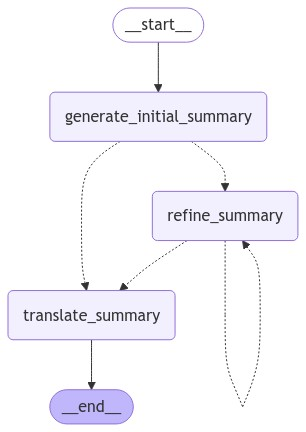

In [ ]:
Image(summarizer_app.get_graph().draw_mermaid_png())

#7. Executing the summarization process

In [ ]:
# Define the main function
async def main():
    # Prepare the input state for the graph
    input_state = {
        "contents": [chunk.page_content for chunk in texts_chunks],
        "index": 0,
        "summary": "",
    }

    # Run the summarization graph and capture the final result
    final_result = None
    async for result in summarizer_app.astream(
        input_state,
        stream_mode="values"
    ):
        final_result = result  # keep updating until the final result

    # Print the final translated summary
    if final_result:
        print("Summary :", final_result['summary'])
        print("French summary:", final_result['translation'])
    else:
        print("No summary/translation generated.")

In [ ]:
#Run
await main()

Summary : This is a revised version of an earlier version of this article. We have added a number of new points to the original version. We are happy to clarify that this is not the case with this version of the story. We hope that this will make it easier for people to understand what is going on in this story.
French summary: C'est une version révisée d'une version antérieure de cet article. Nous avons ajouté un certain nombre de nouveaux points à la version originale. Nous sommes heureux de préciser que ce n'est pas le cas avec cette version de l'histoire. Nous espérons que cela permettra aux gens de mieux comprendre ce qui se passe dans cette histoire.
